In [14]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA


rng = np.random.default_rng(42)
x = rng.uniform(-3,3,600)
y = rng.uniform(-3,3,600)
healthy = ((x**2 + y**2) < 4).astype(int)
df = pd.DataFrame({"x": x, "y": y, "healthy": healthy})

In [15]:
cities = ['KTM', 'PKR', 'BRT']
rows_per_city = 40
data = {
    'city': np.repeat(cities, rows_per_city),
    'sales': np.concatenate([
        np.random.randint(100, 160, rows_per_city),  # KTM sales range
        np.random.randint(70, 120, rows_per_city),   # PKR sales range
        np.random.randint(40, 90, rows_per_city),    # BRT sales range
    ])
}
df = pd.DataFrame(data)
df

,city,sales
0,KTM,158
1,KTM,140
2,KTM,138
3,KTM,139
4,KTM,149
...,...,...
115,BRT,70
116,BRT,66
117,BRT,51
118,BRT,51


pipe = make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000))
raw = df[["x" , "y"]]
print(cross_val_score(pipe , raw , healthy , cv = 5).mean())

eng = raw.assign(dist2=df["x"]**2 + df["y"]**2)
print(cross_val_score(pipe, eng, healthy, cv=5).mean())

In [21]:
cities = ['KTM', 'PKR', 'BRT']
rows_per_city = 40
data = {
    'city': np.repeat(cities, rows_per_city),
    'sales': np.concatenate([
        np.random.randint(100, 160, rows_per_city),  # KTM sales range
        np.random.randint(70, 120, rows_per_city),   # PKR sales range
        np.random.randint(40, 90, rows_per_city),    # BRT sales range
    ])
}
df = pd.DataFrame(data)
df



,city,sales
0,KTM,104
1,KTM,100
2,KTM,121
3,KTM,106
4,KTM,131
...,...,...
115,BRT,68
116,BRT,79
117,BRT,55
118,BRT,80


In [22]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

COLUMN TRANSFER

In [43]:
categorical = df.select_dtypes(include=['object','category']).columns
numerical = df.select_dtypes(exclude=['object','category']).columns

crf = ColumnTransformer([
    ("num" , StandardScaler() , numerical),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])
X_transformed = crf.fit_transform(df)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)


# ks = []
# inertias = []
# for k in range(2,12):
#     km = KMeans(k , n_init=10 , random_state=43 ,)
#     labels = km.fit_predict(X_pca)
#     inertias.append(km.inertia_)
#     ks.append(k)
# print(ks)
# print(inertias)
    


In [45]:
km = KMeans(n_clusters=3 , n_init = 10 , random_state= 42)
labels = km.fit_predict(X_pca)


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


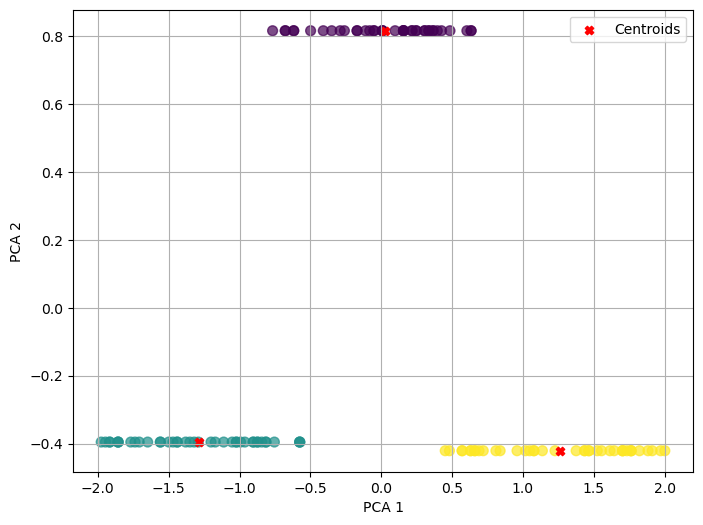

In [46]:
x_axis_data = X_pca[:,0]
y_axis_data = X_pca[:,1]

#Setu the canvas size:
plt.figure(figsize=(8, 6))
plt.scatter(x_axis_data , y_axis_data , c = labels , cmap = "viridis" , s = 50 , alpha = 0.7) # Matplotlib maps each unique label value to a distinct color using c ,  si is marker size

centroids_x = km.cluster_centers_[:,0]
centroids_y = km.cluster_centers_[:,1]

plt.scatter(centroids_x , centroids_y , c = 'red' , marker = 'X' , label = 'Centroids')
plt.xlabel('PCA 1')  
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

In [31]:

categorical = X.select_dtypes(include=['object','category']).columns
numerical = X.select_dtypes(exclude=['object','category']).columns

pre = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

model = {
    "Logistic Regression": Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000))]),
    "Decision Tree": Pipeline([("pre", pre), ("clf", DecisionTreeClassifier(max_depth=4))]),
    "RandomForest": Pipeline([("pre", pre), ("clf", RandomForestClassifier(n_estimators=300))]),
}



NameError: name 'X' is not defined